In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [14]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [16]:
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add Cluster Column
df['Cluster'] = clusters

print("\nCluster Counts:")
print(df['Cluster'].value_counts())



Cluster Counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [19]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)',
                                         'Spending Score (1-100)',
                                         'Age']].mean()

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)        Age
Cluster                                                       
0                 55.296296               49.518519  42.716049
1                 86.538462               82.128205  32.692308
2                 25.727273               79.363636  25.272727
3                 88.200000               17.114286  41.114286
4                 26.304348               20.913043  45.217391


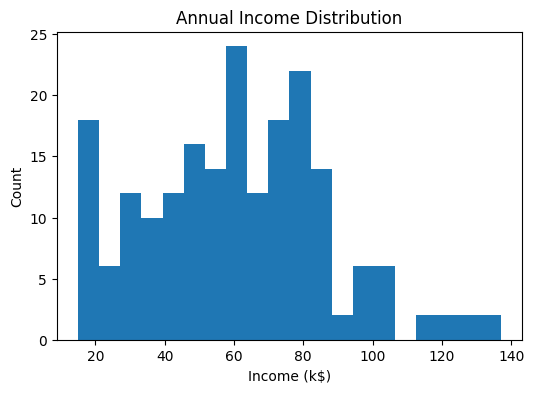

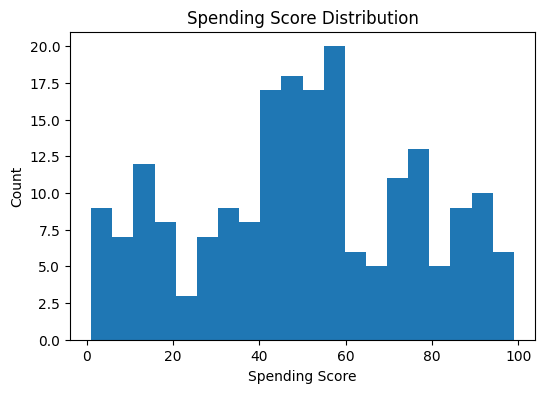

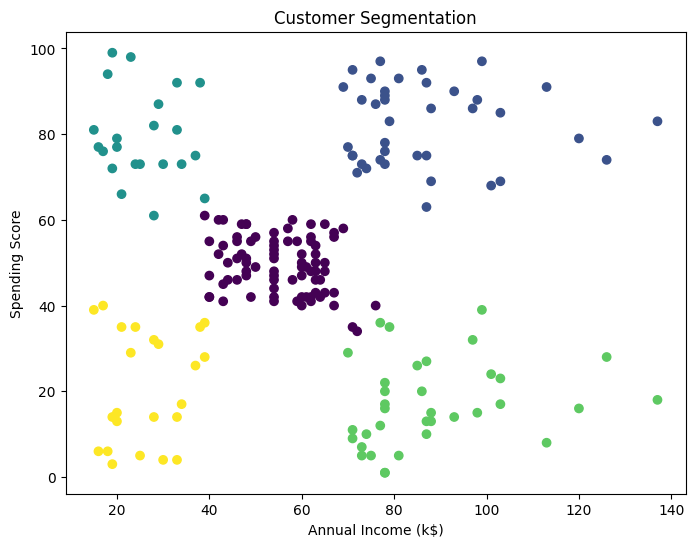

In [21]:
# Annual Income Distribution
plt.figure(figsize=(6,4))
plt.hist(df['Annual Income (k$)'], bins=20)
plt.title("Annual Income Distribution")
plt.xlabel("Income (k$)")
plt.ylabel("Count")
plt.show()

# Spending Score Distribution
plt.figure(figsize=(6,4))
plt.hist(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

